## The four-step training loop 
1- Forward Propagation: it's the first output of the neural network with random weights and bias, for each input we do the dot product then an activation function in the hidden layers then another activation function and dot product for the output layer.

2- loss function: for the first output we do a loss function to calculate how wrong the prediction is.

3- Backpropagation: using the chain rule, we compute how much each weight contributed to the loss.

4- Update: is the process of updating the weights and the bias to reach the minimum loss 

we repeat these steps until we reach the best results

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24540\1709448657.py:49: RuntimeWarning: overflow encountered in square
  loss = np.mean((prediction - Y) ** 2)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24540\1709448657.py:64: RuntimeWarning: overflow encountered in matmul
  d_hidden_output = d_prediction @ W2.T
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24540\1709448657.py:68: RuntimeWarning: invalid value encountered in multiply
  d_hidden_input = d_hidden_output * (1 - hidden_output ** 2)


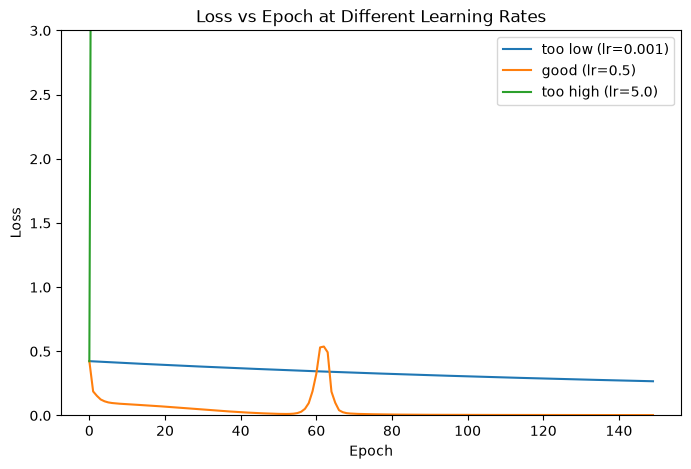

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)  # so we get the same random numbers every time we run this

# ---- Our tiny "dataset" ----
# We want the network to learn: y = x^2
# X is our input values, Y is the correct answer for each input
X = np.linspace(-1, 1, 50).reshape(-1, 1)   # 50 input numbers between -1 and 1
Y = X ** 2                                   # the correct answer for each input

# ---- Set up a tiny network: 1 input -> 4 hidden neurons -> 1 output ----
# Just like your example, but instead of typing weights1, weights2, weights3, weights4
# one by one, we let numpy hold all 4 neurons' weights in one small table (array).

W1 = np.random.randn(1, 4) * 0.5   # weights connecting input -> 4 hidden neurons
b1 = np.zeros((1, 4))              # bias for each of the 4 hidden neurons

W2 = np.random.randn(4, 1) * 0.5   # weights connecting 4 hidden neurons -> output
b2 = np.zeros((1, 1))              # bias for the output neuron

# Save the starting point so every learning rate test starts from the SAME weights
W1_start, b1_start, W2_start, b2_start = W1.copy(), b1.copy(), W2.copy(), b2.copy()


def train_network(learning_rate, number_of_epochs):
    # Start fresh from the same initial weights every time this function is called
    W1 = W1_start.copy()
    b1 = b1_start.copy()
    W2 = W2_start.copy()
    b2 = b2_start.copy()

    loss_history = []  # we will record the loss at every epoch, to plot it later

    for epoch in range(number_of_epochs):

        # ===== STEP 1: FORWARD PASS =====
        # (this is the exact same idea as your v1, a1, v3, a3 code from before,
        #  just done for 4 neurons at once instead of writing each one by hand)
        hidden_input = X @ W1 + b1       # dot product + bias, for all 4 neurons
        hidden_output = np.tanh(hidden_input)   # activation function

        final_input = hidden_output @ W2 + b2   # dot product + bias for output
        prediction = final_input                # (no activation here, plain number)

        # ===== STEP 2: LOSS =====
        # How far off is our prediction from the real answer Y?
        # We square the difference so negative and positive errors don't cancel out.
        loss = np.mean((prediction - Y) ** 2)
        loss_history.append(loss)

        # ===== STEP 3: BACKPROPAGATION =====
        # We go backward from the loss to figure out how much each weight
        # is responsible for the error. Each line below is one "link" in the chain.

        # how much the loss changes with respect to the prediction
        d_prediction = 2 * (prediction - Y) / len(X)

        # how much the loss changes with respect to W2 and b2
        d_W2 = hidden_output.T @ d_prediction
        d_b2 = d_prediction.sum(axis=0, keepdims=True)

        # how much the loss changes with respect to hidden_output
        d_hidden_output = d_prediction @ W2.T

        # how much the loss changes with respect to hidden_input
        # (we multiply by the derivative of tanh here)
        d_hidden_input = d_hidden_output * (1 - hidden_output ** 2)

        # how much the loss changes with respect to W1 and b1
        d_W1 = X.T @ d_hidden_input
        d_b1 = d_hidden_input.sum(axis=0, keepdims=True)

        # ===== STEP 4: UPDATE (gradient descent) =====
        # Move each weight a small step in the direction that reduces the loss
        W1 = W1 - learning_rate * d_W1
        b1 = b1 - learning_rate * d_b1
        W2 = W2 - learning_rate * d_W2
        b2 = b2 - learning_rate * d_b2

    return loss_history


# ---- Try 3 different learning rates ----
loss_too_low  = train_network(learning_rate=0.001, number_of_epochs=150)
loss_good     = train_network(learning_rate=0.5,   number_of_epochs=150)
loss_too_high = train_network(learning_rate=5.0,   number_of_epochs=150)

# ---- Plot all three on one chart ----
plt.figure(figsize=(8, 5))
plt.plot(loss_too_low,  label="too low (lr=0.001)")
plt.plot(loss_good,     label="good (lr=0.5)")
plt.plot(loss_too_high, label="too high (lr=5.0)")

plt.title("Loss vs Epoch at Different Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.ylim(0, 3)   # keep the chart readable even though "too high" explodes
plt.legend()
plt.show()

Backpropagation starts from the loss and works backward through the network to compute how much each weight used in the dot product operations was responsible for the error. Since a weight's effect on the loss isn't direct, it passes through all the hidden layers on its way to the output, we use the chain rule from calculus, which lets us calculate this effect by multiplying the effect of each layer by the effect of the layer that comes after it, moving backward. Once we've computed this effect (the gradient) for each weight, we use it in the update step through gradient descent, adjusting the weights in the direction that reduces the loss, until we reach the lowest loss possible.

## The same work on The Project(Medical DataSet)

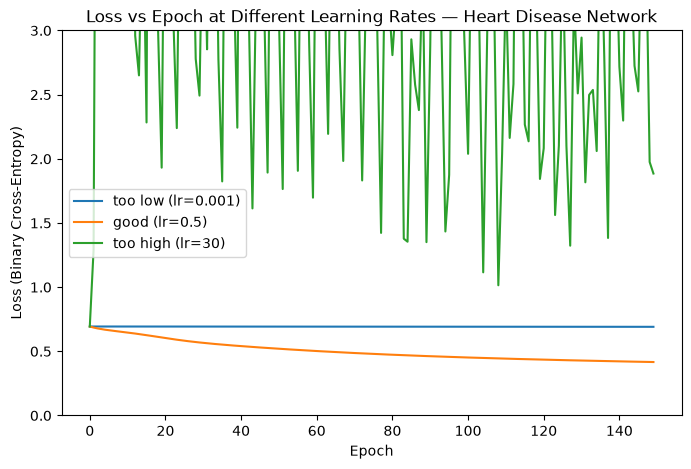

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(0)

# ==== Data (same preprocessing as before) ====
df = pd.read_csv('C:/Users/Lenovo/OneDrive/Desktop/BinX training/Project/data/heart_disease_clean.csv')
df['Result'] = df['Result'].map({'negative': 0, 'positive': 1})
X = df.drop(columns=['Result']).values
y = df['Result'].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# ==== Same initial weights for a fair comparison across learning rates ====
n_features = X_train_scaled.shape[1]
hidden_size = 8
W1_init = np.random.randn(n_features, hidden_size) * 0.1
b1_init = np.zeros((1, hidden_size))
W2_init = np.random.randn(hidden_size, 1) * 0.1
b2_init = np.zeros((1, 1))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def train(lr, epochs=150):
    W1, b1, W2, b2 = W1_init.copy(), b1_init.copy(), W2_init.copy(), b2_init.copy()
    losses = []
    for epoch in range(epochs):
        z1 = X_train_scaled @ W1 + b1
        a1 = np.tanh(z1)
        z2 = a1 @ W2 + b2
        pred = sigmoid(z2)

        eps = 1e-8
        pred_clipped = np.clip(pred, eps, 1 - eps)
        loss = -np.mean(y_train*np.log(pred_clipped) + (1-y_train)*np.log(1-pred_clipped))
        losses.append(loss)

        dz2 = (pred - y_train) / len(X_train_scaled)
        dW2 = a1.T @ dz2
        db2 = dz2.sum(0, keepdims=True)
        da1 = dz2 @ W2.T
        dz1 = da1 * (1 - a1**2)
        dW1 = X_train_scaled.T @ dz1
        db1 = dz1.sum(0, keepdims=True)

        W1 -= lr*dW1; b1 -= lr*db1
        W2 -= lr*dW2; b2 -= lr*db2
    return losses

# ==== Run at 3 learning rates ====
loss_too_low  = train(lr=0.001, epochs=150)
loss_good     = train(lr=0.5,   epochs=150)
loss_too_high = train(lr=30,    epochs=150)

# ==== Plot ====
plt.figure(figsize=(8,5))
plt.plot(loss_too_low,  label="too low (lr=0.001)")
plt.plot(loss_good,     label="good (lr=0.5)")
plt.plot(loss_too_high, label="too high (lr=30)")
plt.xlabel("Epoch"); plt.ylabel("Loss (Binary Cross-Entropy)")
plt.title("Loss vs Epoch at Different Learning Rates — Heart Disease Network")
plt.ylim(0, 3)
plt.legend()
plt.show()